In [1]:
import time
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import cuda

In [2]:
def describe_gpu():
    if not cuda.is_available():
        raise RuntimeError("CUDA недоступна. Проверьте, что среда запущена с GPU.")

    gpu = cuda.get_current_device()
    print("Бенчмарк CUDA для измерения скорости редукции данных")
    print("-" * 42)
    print(f"Устройство: {gpu.name}")
    print(f"Ограничение на число потоков в одном блоке: {gpu.MAX_THREADS_PER_BLOCK}")
    print("-" * 42)


describe_gpu()

Бенчмарк CUDA для измерения скорости редукции данных
------------------------------------------
Устройство: Tesla T4
Ограничение на число потоков в одном блоке: 1024
------------------------------------------


In [3]:
BLOCK_SIZE = 256

@cuda.jit
def block_reduce_sum(input_data, partial_data, n):
    local_id = cuda.threadIdx.x
    global_id = cuda.blockIdx.x * cuda.blockDim.x + local_id
    step = cuda.blockDim.x * cuda.gridDim.x

    shared = cuda.shared.array(BLOCK_SIZE, dtype=np.float32)

    acc = 0.0

    i = global_id
    while i < n:
        acc += input_data[i]
        i += step

    shared[local_id] = acc
    cuda.syncthreads()

    stride = cuda.blockDim.x // 2
    while stride > 0:
        if local_id < stride:
            shared[local_id] += shared[local_id + stride]
        cuda.syncthreads()
        stride //= 2

    if local_id == 0:
        partial_data[cuda.blockIdx.x] = shared[0]

In [4]:
def python_loop_sum(values):
    start = time.perf_counter()

    total = 0.0
    for item in values:
        total += float(item)

    elapsed = time.perf_counter() - start
    return total, elapsed


def numpy_sum(values):
    start = time.perf_counter()
    total = float(np.sum(values, dtype=np.float64))
    elapsed = time.perf_counter() - start
    return total, elapsed


def cuda_sum(values, repeats=5):
    values = np.asarray(values, dtype=np.float32)
    n = values.size
    d_current = cuda.to_device(values)

    def reduce_once(d_input, length):
        blocks = min(2048, max(1, (length + BLOCK_SIZE - 1) // BLOCK_SIZE))
        d_output = cuda.device_array(blocks, dtype=np.float32)
        block_reduce_sum[blocks, BLOCK_SIZE](d_input, d_output, length)
        return d_output, blocks

    d_tmp, tmp_len = reduce_once(d_current, n)
    cuda.synchronize()

    timings = []
    final_value = None

    for _ in range(repeats):
        d_work = d_current
        length = n

        start = time.perf_counter()

        while length > 1:
            d_work, length = reduce_once(d_work, length)

        cuda.synchronize()
        timings.append(time.perf_counter() - start)

        final_value = float(d_work.copy_to_host()[0])

    return final_value, float(np.mean(timings))

In [5]:
@dataclass
class ExperimentConfig:
    sizes: tuple = (2**10, 2**12, 2**14, 2**16, 2**18, 2**20, 2**22)
    seed: int = 42
    repeats_gpu: int = 5


config = ExperimentConfig()
rng = np.random.default_rng(config.seed)

print("Размер вектора:", config.sizes)
print("Повторения выполнения на GPU:", config.repeats_gpu)

Размер вектора: (1024, 4096, 16384, 65536, 262144, 1048576, 4194304)
Повторения выполнения на GPU: 5


In [6]:
records = []

for n in config.sizes:
    vector = rng.random(n, dtype=np.float32)

    loop_total, loop_time = python_loop_sum(vector)
    np_total, np_time = numpy_sum(vector)
    gpu_total, gpu_time = cuda_sum(vector, repeats=config.repeats_gpu)

    abs_error = abs(gpu_total - np_total)
    rel_error = abs_error / abs(np_total)

    records.append({
        "Размер N": n,
        "Цикл Python, с": loop_time,
        "NumPy, s": np_time,
        "CUDA, s": gpu_time,
        "Ускорение относительно цикла": loop_time / gpu_time,
        "Абсолютная ошибка GPU": abs_error,
        "Относительная ошибка GPU": rel_error,
        "Корректно": np.isclose(gpu_total, np_total, rtol=1e-4, atol=1e-2),
    })

    print(
        f"N={n:>8} | цикл={loop_time:.6f}s | "
        f"cuda={gpu_time:.6f}s | ускорение={loop_time / gpu_time:.2f}x | "
        f"корректно={records[-1]['Корректно']}"
    )

summary = pd.DataFrame(records)
summary

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: Numba

N=    1024 | цикл=0.000168s | cuda=0.000498s | ускорение=0.34x | корректно=True
N=    4096 | цикл=0.000381s | cuda=0.000281s | ускорение=1.35x | корректно=True
N=   16384 | цикл=0.001376s | cuda=0.000325s | ускорение=4.23x | корректно=True
N=   65536 | цикл=0.005374s | cuda=0.000217s | ускорение=24.77x | корректно=True
N=  262144 | цикл=0.021464s | cuda=0.000325s | ускорение=66.04x | корректно=True
N= 1048576 | цикл=0.104138s | cuda=0.000415s | ускорение=251.19x | корректно=True
N= 4194304 | цикл=0.350548s | cuda=0.000372s | ускорение=943.15x | корректно=True


,Размер N,"Цикл Python, с","NumPy, s","CUDA, s",Ускорение относительно цикла,Абсолютная ошибка GPU,Относительная ошибка GPU,Корректно
0,1024,0.000168,0.000085,0.000498,0.337310,0.000002,3.699909e-09,True
1,4096,0.000381,0.000036,0.000281,1.352322,0.000043,2.094071e-08,True
2,16384,0.001376,0.000036,0.000325,4.230057,0.000109,1.339960e-08,True
3,65536,0.005374,0.000075,0.000217,24.774628,0.000617,1.880951e-08,True
4,262144,0.021464,0.000205,0.000325,66.036300,0.005977,4.557339e-08,True
5,1048576,0.104138,0.000786,0.000415,251.188625,0.000538,1.026609e-09,True
6,4194304,0.350548,0.002940,0.000372,943.148732,0.049230,2.347018e-08,True


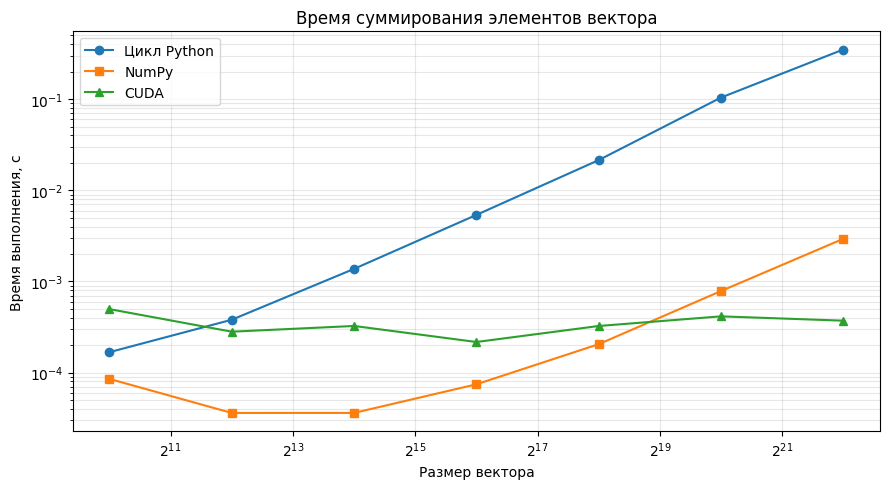

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(summary["Размер N"], summary["Цикл Python, с"], marker="o", label="Цикл Python")
plt.plot(summary["Размер N"], summary["NumPy, s"], marker="s", label="NumPy")
plt.plot(summary["Размер N"], summary["CUDA, s"], marker="^", label="CUDA")

plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel("Размер вектора")
plt.ylabel("Время выполнения, с")
plt.title("Время суммирования элементов вектора")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

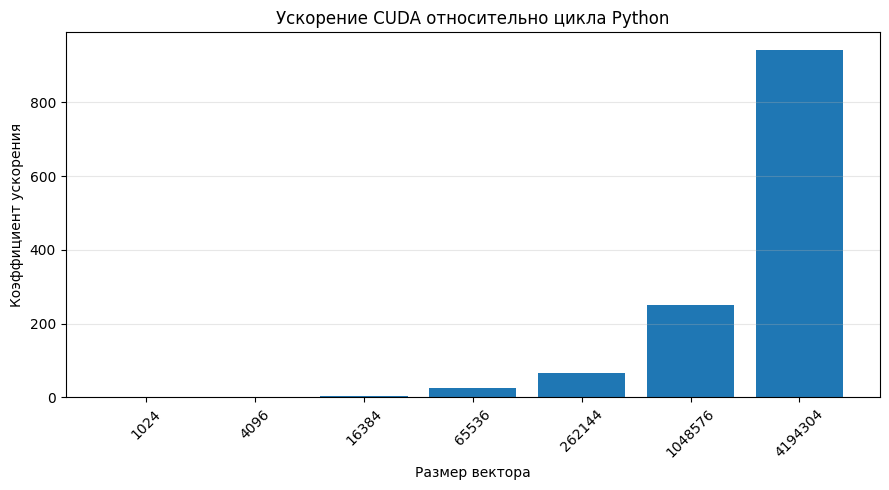

In [8]:
plt.figure(figsize=(9, 5))

plt.bar(summary["Размер N"].astype(str), summary["Ускорение относительно цикла"])

plt.xlabel("Размер вектора")
plt.ylabel("Коэффициент ускорения")
plt.title("Ускорение CUDA относительно цикла Python")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
best_row = summary.loc[summary["Ускорение относительно цикла"].idxmax()]

print("Итоговый отчёт")
print("-" * 42)
print(f"Максимальный размер вектора: {int(summary['Размер N'].max())}")
print(f"Максимальное ускорение: {best_row['Ускорение относительно цикла']:.2f}x")
print(f"Размер вектора при максимальном ускорении: {int(best_row['Размер N'])}")
print(f"Все результаты CUDA корректны: {bool(summary['Корректно'].all())}")
print(f"Максимальная относительная ошибка: {summary['Относительная ошибка GPU'].max():.3e}")

Итоговый отчёт
------------------------------------------
Максимальный размер вектора: 4194304
Максимальное ускорение: 943.15x
Размер вектора при максимальном ускорении: 4194304
Все результаты CUDA корректны: True
Максимальная относительная ошибка: 4.557e-08
